# Environment Setup & Data Loading
This cell mounts your Google Drive and loads the raw dataset using automatic separator detection.

In [58]:
import os
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Mount Google Drive for persistent storage
if not os.path.exists("/content/drive"):
    drive.mount("/content/drive")

# 2. Define project paths
FOLDER = "/content/drive/MyDrive/TARDIS-PROJECT"
INPUT_PATH = os.path.join(FOLDER, "dataset.csv")
OUTPUT_PATH = os.path.join(FOLDER, "cleaned_dataset.csv")

# 3. Read the raw dataset with semicolon delimiter
df = pd.read_csv(INPUT_PATH, sep=";", na_values=["N/A", ""])
print(f"✅ Raw dataset loaded: {len(df):,} rows.")

✅ Raw dataset loaded: 10,840 rows.


# Duplicate Removal
This cell eliminates identical rows to prevent artificial weight or bias in our statistics.

In [59]:
# Remove exact duplicate rows from the dataset
initial_rows = len(df)
df = df.drop_duplicates()
print(f"🗑️ Duplicates removed: {initial_rows - len(df)}")
print(f"   Remaining rows: {len(df):,}")

🗑️ Duplicates removed: 178
   Remaining rows: 10,662


# Basic Date Parsing
This cell attempts a standard conversion of the Date column without handling any tricky text traps yet.

In [60]:
# Convert the Date column to datetime format (unparseable values will become NaT)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print("📅 Date column parsed.")
print(f"   Invalid dates found (NaT): {df['Date'].isna().sum()}")

📅 Date column parsed.
   Invalid dates found (NaT): 822


# Feature Engineering (V1)
This cell extracts basic temporal features required by the project guidelines to capture seasonal and yearly trends.

In [61]:
# Extract basic Year and Month columns from the parsed Date
df["Year"] = df["Date"].dt.year.astype("Int64")
df["Month"] = df["Date"].dt.month.astype("Int64")

print("✨ Basic feature engineering complete: 'Year' and 'Month' columns added.")

✨ Basic feature engineering complete: 'Year' and 'Month' columns added.


# Final Filtering & Export
This cell drops any rows missing critical data (like the target variable or routing stations) because machine learning algorithms cannot train on missing labels or targets.

In [62]:
# Define critical columns required for baseline prediction models
critical_cols = [
    "Date",
    "Departure station",
    "Arrival station",
    "Average delay of all trains at arrival",
]

# Drop rows where any critical information is missing
df_cleaned = df.dropna(subset=critical_cols).copy()
print(f"🧼 Rows kept after structural cleaning: {len(df_cleaned):,}")

# Save the V1 baseline dataset to Google Drive
df_cleaned.to_csv(OUTPUT_PATH, index=False)
print(f"💾 Baseline dataset (V1) successfully saved to: {OUTPUT_PATH}")

# Quick look at the resulting data structure
df_cleaned.head(3)

🧼 Rows kept after structural cleaning: 8,217
💾 Baseline dataset (V1) successfully saved to: /content/drive/MyDrive/TARDIS-PROJECT/cleaned_dataset.csv


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",Year,Month
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,NaN,5.0,NaN,289.0,11.247809,...,44.0,8.0,36.134454,31.092437,10.924370,15.966387,5.042017,75.91573,2018,1
1,2018-01-01,National,LA ROCHELLE VILLE,PARIS MONTPARNASSE,165.0,222.0,NaN,NaN,8.0,2.875000,...,5.0,NaN,15.384615,30.769231,38.461538,11.538462,3.846154,0.00000,2018,1
2,2018-01-01,National,PARIS MONTPARNASSE,QUIMPER,220.0,248.0,1.0,NaN,37.0,9.501351,...,17.0,7.0,26.923077,38.461538,NaN,19.230769,0.000000,0.00000,2018,1


## Exploratory Data Analysis (V1 Baseline)

Now that the baseline dataset is exported, we generate our first quick visualizations.
At this stage, we intentionally keep the data as close to raw as possible to observe how inconsistencies affect our plots and to justify future data cleaning iterations.

# Visualization Environment Setup
This cell initializes the plotting libraries and sets up the global visual style for all upcoming charts.

In [63]:
# Cell 6: Visualization Environment Setup
import matplotlib.pyplot as plt
import seaborn as sns

# Set global Seaborn theme and figure parameters for consistent rendering
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})
print("📊 Visualization environment configured successfully.")

📊 Visualization environment configured successfully.


## Target Variable Distribution (V1)
This cell plots the distribution of our target variable (Average delay of all trains at arrival) without filtering outliers to see the raw shape of the data.

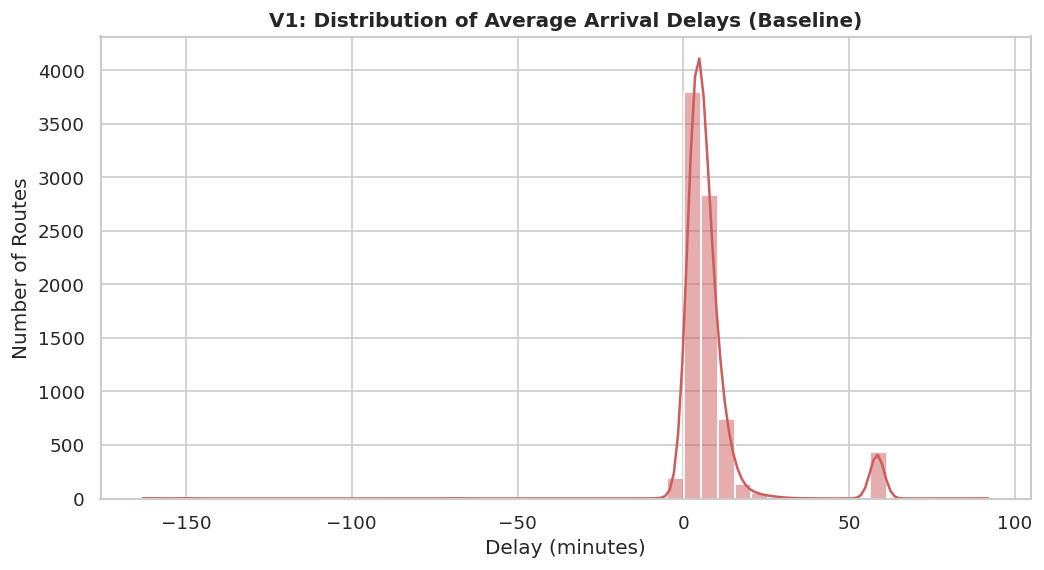

In [64]:
# Cell 7: Target Variable Distribution (V1)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(
    df_cleaned["Average delay of all trains at arrival"],
    bins=50,
    kde=True,
    color="indianred",
)

plt.title(
    "V1: Distribution of Average Arrival Delays (Baseline)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of Routes")
plt.show()

## Monthly Seasonality (V1)
This cell groups the baseline data by month to calculate the average delay and trace a preliminary seasonal trend curve.

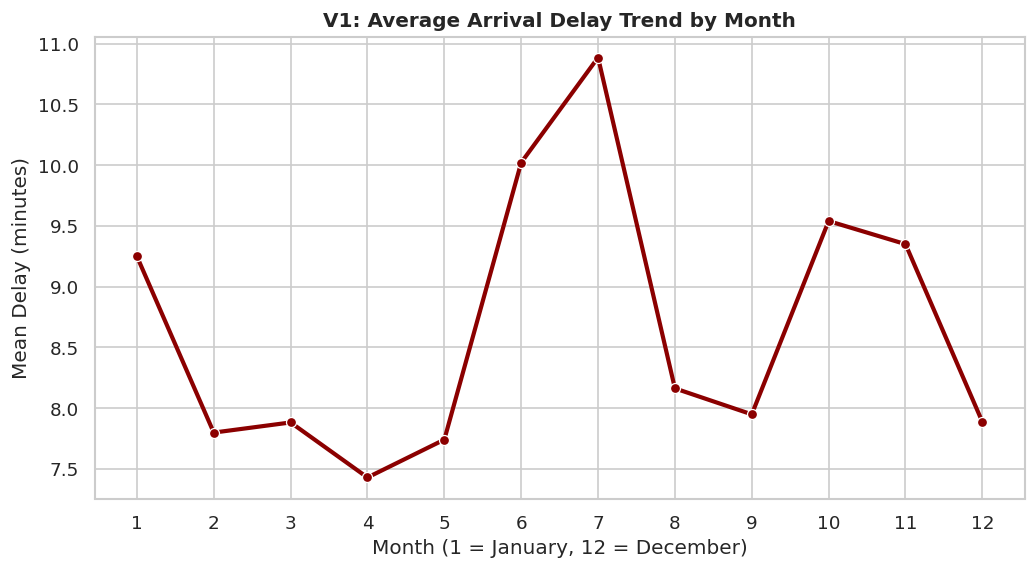

In [65]:
# Cell 8: Monthly Seasonality Analysis (V1)
monthly_trend_v1 = (
    df_cleaned.groupby("Month")["Average delay of all trains at arrival"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=monthly_trend_v1,
    x="Month",
    y="Average delay of all trains at arrival",
    marker="o",
    color="darkred",
    linewidth=2.5,
)

plt.title("V1: Average Arrival Delay Trend by Month", fontsize=12, fontweight="bold")
plt.xticks(range(1, 13))
plt.xlabel("Month (1 = January, 12 = December)")
plt.ylabel("Mean Delay (minutes)")
plt.show()

## Top 10 Departure Stations (V1)
This cell isolates the top 10 departure stations with the highest mean delay before applying our advanced text matching pipeline, showing corrupted station names and potential ghost categories.

/tmp/ipykernel_7374/4259777355.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data_v1, x="Average delay of all trains at arrival", y="Departure station", palette="coolwarm")


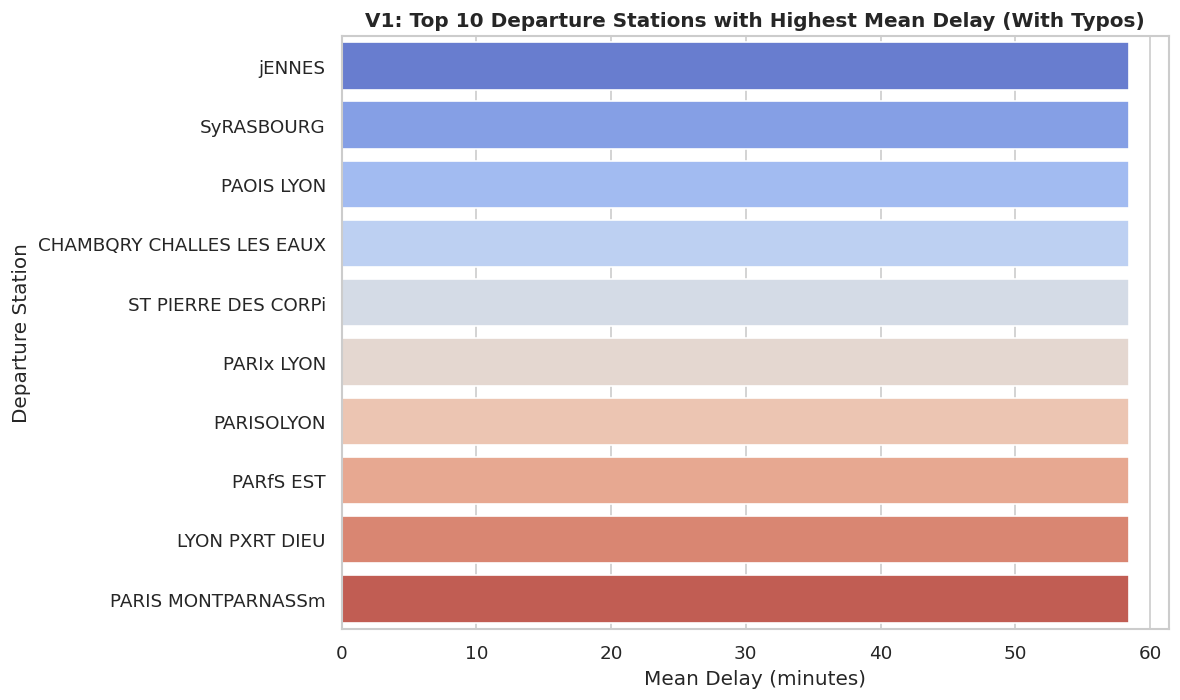

In [66]:
# Cell 9: Top 10 Worst Performing Departure Stations (V1)
top_10_stations_v1 = (
    df_cleaned.groupby("Departure station")["Average delay of all trains at arrival"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Reset index and cast to string to fix Seaborn categorical layout compression
plot_data_v1 = top_10_stations_v1.reset_index()
plot_data_v1["Departure station"] = plot_data_v1["Departure station"].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data_v1,
    x="Average delay of all trains at arrival",
    y="Departure station",
    palette="coolwarm",
)

plt.title(
    "V1: Top 10 Departure Stations with Highest Mean Delay (With Typos)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Mean Delay (minutes)")
plt.ylabel("Departure Station")
plt.tight_layout()
plt.show()

---

# Part 2: Advanced Data Cleaning & Feature Engineering (V2 Expert)

## Limitations of V1 & Objectives for V2
After analyzing our baseline visualizations and running our baseline model, we discovered that a simple structural clean is not enough. The dataset contains severe hidden anomalies that compromise predictive modeling:
1. **System Sentinel Values:** Placeholder floats like `1702.59` minutes skew our statistical averages.
2. **Text Corruption & Typos:** Over 500 duplicate station variants fragment our categorical categories.

In this section, we build our **Version 2 pipeline** to perform advanced data cleaning and automated string matching.

### Sentinel / Magic Values Replacement
We identify and replace non-integer system placeholders with true `NaN` values to obtain an honest and accurate statistical distribution of train delays.

In [67]:
# Cell 10: Sentinel Values Replacement
# Define the known rounded sentinel floats from the source pipeline
MAGIC_VALUES = {
    "Average journey time": [1702.594, 0.0],
    "Number of scheduled trains": [2681.206],
    "Number of cancelled trains": [94.946],
    "Number of trains delayed at departure": [872.292],
    "Number of trains delayed at arrival": [365.283],
    "Number of trains delayed > 15min": [260.393],
    "Number of trains delayed > 30min": [124.672],
    "Number of trains delayed > 60min": [46.455],
}

total_replaced = 0

# Loop through columns to locate and neutralize magic values
for col, sentinel_list in MAGIC_VALUES.items():
    for sentinel in sentinel_list:
        mask = df_cleaned[col].round(3) == sentinel
        n = mask.sum()
        df_cleaned.loc[mask, col] = np.nan
        total_replaced += n
        print(f"   {col}: {n} sentinel cells ({sentinel}) -> NaN")

print(f"\n✅ Total sentinel cells replaced in df_cleaned: {total_replaced:,}")

   Average journey time: 402 sentinel cells (1702.594) -> NaN
   Average journey time: 50 sentinel cells (0.0) -> NaN
   Number of scheduled trains: 396 sentinel cells (2681.206) -> NaN
   Number of cancelled trains: 414 sentinel cells (94.946) -> NaN
   Number of trains delayed at departure: 392 sentinel cells (872.292) -> NaN
   Number of trains delayed at arrival: 410 sentinel cells (365.283) -> NaN
   Number of trains delayed > 15min: 378 sentinel cells (260.393) -> NaN
   Number of trains delayed > 30min: 399 sentinel cells (124.672) -> NaN
   Number of trains delayed > 60min: 390 sentinel cells (46.455) -> NaN

✅ Total sentinel cells replaced in df_cleaned: 3,231


### Station Name Normalization via Fuzzy Matching
To fix spelling errors and remove ghost stations (like residual text 'NAN'), we build a canonical list of trusted stations based on frequency ($\ge 15$ occurrences) and apply a 70% string similarity mapping cutoff.

In [68]:
# Cell 11: Advanced Fuzzy Matching Algorithm
import difflib

# Normalize text properties to prevent casing duplicates
for col in ["Departure station", "Arrival station"]:
    df_cleaned[col] = df_cleaned[col].astype(str).str.upper().str.strip()
    df_cleaned[col] = df_cleaned[col].replace("NAN", np.nan)

# Drop rows where station fields are completely missing
df_cleaned.dropna(subset=["Departure station", "Arrival station"], inplace=True)

# Isolate frequent stations to create our reference map
all_station_names = pd.concat(
    [df_cleaned["Departure station"], df_cleaned["Arrival station"]]
)
name_counts = all_station_names.value_counts()
canonical_stations = name_counts[name_counts >= 15].index.tolist()

# Run similarity checks to match dirty inputs with canonical reference names
unique_dirty_names = all_station_names.unique()
station_mapping = {}

for name in unique_dirty_names:
    if name in canonical_stations:
        station_mapping[name] = name
    else:
        matches = difflib.get_close_matches(name, canonical_stations, n=1, cutoff=0.70)
        station_mapping[name] = matches[0] if matches else name

# Map corrected targets back to our dataframe columns
df_cleaned["Departure station"] = df_cleaned["Departure station"].map(station_mapping)
df_cleaned["Arrival station"] = df_cleaned["Arrival station"].map(station_mapping)

print(
    f"✨ Station typos corrected. Verified canonical stations: {len(canonical_stations)}"
)

✨ Station typos corrected. Verified canonical stations: 59


### Advanced Feature Engineering & V2 Export
We enrich the dataset with advanced operational context metrics (`Season`, `Route`, `Cancellation rate`) and overwrite the single source of truth `cleaned_dataset.csv`.

In [69]:
# Cell 12: Advanced Feature Engineering & Overwriting Output
# Handle target variable extreme operational bugs
EXTREME_NEG_THRESHOLD = -15.0
extreme_mask = (
    df_cleaned["Average delay of all trains at arrival"] < EXTREME_NEG_THRESHOLD
)
df_cleaned.loc[extreme_mask, "Average delay of all trains at arrival"] = np.nan
df_cleaned.dropna(subset=["Average delay of all trains at arrival"], inplace=True)

# Build descriptive operational variables
SEASON_MAP = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn",
}
df_cleaned["Season"] = df_cleaned["Month"].map(SEASON_MAP).astype("category")
df_cleaned["Route"] = (
    df_cleaned["Departure station"].astype(str)
    + " → "
    + df_cleaned["Arrival station"].astype(str)
)

# Calculate contextual cancellation rates
df_cleaned["Cancellation rate"] = np.where(
    df_cleaned["Number of scheduled trains"].notna()
    & (df_cleaned["Number of scheduled trains"] > 0),
    df_cleaned["Number of cancelled trains"]
    / df_cleaned["Number of scheduled trains"]
    * 100,
    np.nan,
)

# Convert strings to robust categorical categories
df_cleaned["Departure station"] = df_cleaned["Departure station"].astype("category")
df_cleaned["Arrival station"] = df_cleaned["Arrival station"].astype("category")

# Save the final high-quality output to your Drive folder
df_cleaned.to_csv(OUTPUT_PATH, index=False)
print(f"💾 Cleaned dataset updated successfully at: {OUTPUT_PATH}")
print(
    f"📊 Final structure: {df_cleaned.shape[0]:,} rows × {df_cleaned.shape[1]} columns."
)

💾 Cleaned dataset updated successfully at: /content/drive/MyDrive/TARDIS-PROJECT/cleaned_dataset.csv
📊 Final structure: 8,211 rows × 31 columns.


## 8. Exploratory Data Analysis & Visualizations (V2 Expert)

Now that our advanced cleaning pipeline has processed the dataset, we regenerate our key visualizations. This allows us to visually validate the elimination of anomalies (such as string typos and ghost stations) and compare the refined data distributions with our initial V1 baseline.

## Target Variable Distribution (V2)
This cell plots the distribution of our target variable after removing extreme sentinel outliers to show the clean and accurate distribution shape.

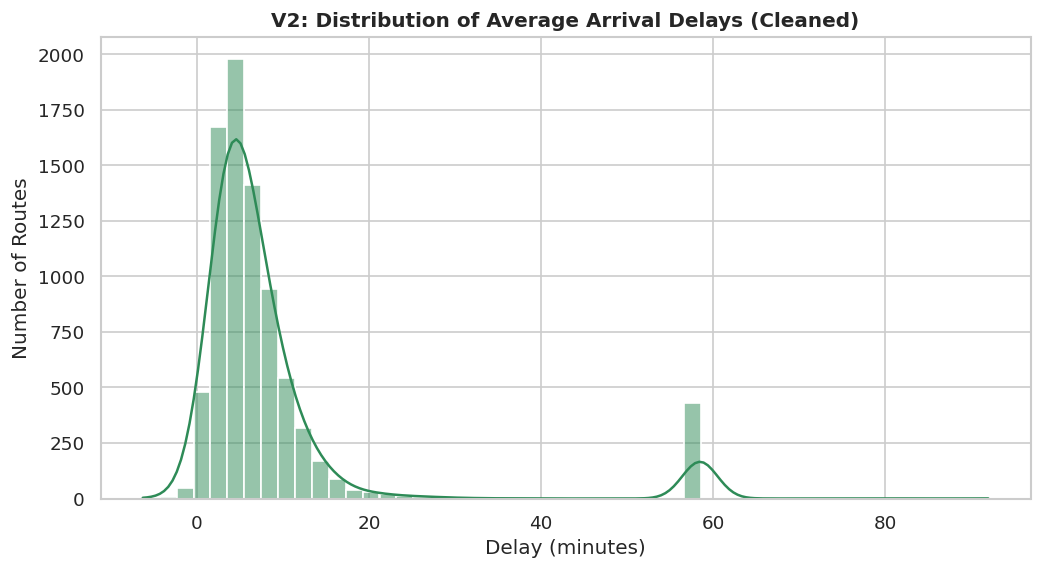

In [70]:
# Cell 13: Cleaned Target Variable Distribution (V2)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
# Plotting the clean distribution without the blinding effect of sentinel values
sns.histplot(
    df_cleaned["Average delay of all trains at arrival"],
    bins=50,
    kde=True,
    color="seagreen",
)

plt.title(
    "V2: Distribution of Average Arrival Delays (Cleaned)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of Routes")
plt.show()

## Monthly Seasonality (V2)
This cell groups the optimized data by month to calculate the average delay and trace an accurate, noise-free seasonal trend curve.

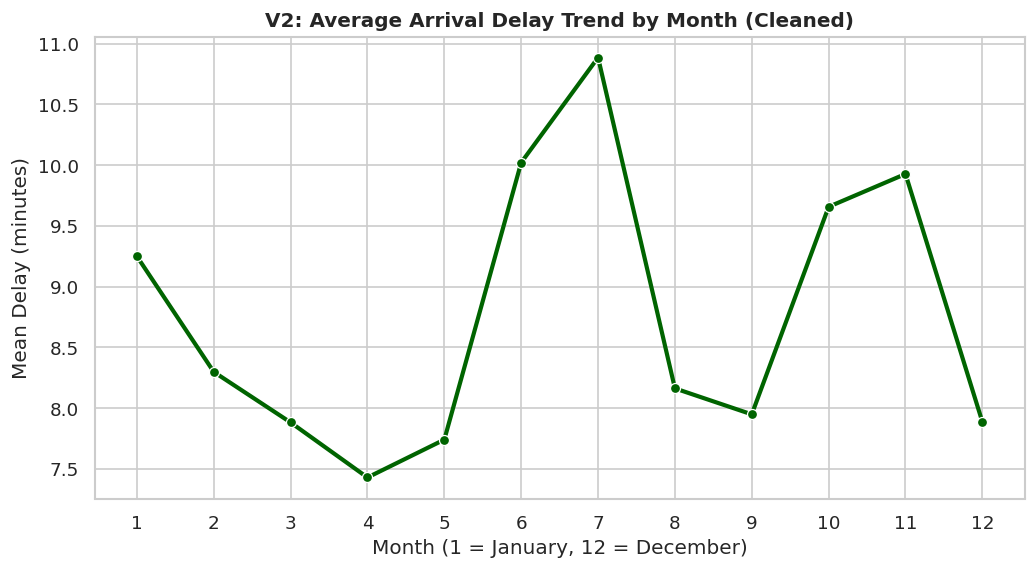

In [71]:
# Cell 14: Cleaned Monthly Seasonality Analysis (V2)
monthly_trend_v2 = (
    df_cleaned.groupby("Month")["Average delay of all trains at arrival"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=monthly_trend_v2,
    x="Month",
    y="Average delay of all trains at arrival",
    marker="o",
    color="darkgreen",
    linewidth=2.5,
)

plt.title(
    "V2: Average Arrival Delay Trend by Month (Cleaned)", fontsize=12, fontweight="bold"
)
plt.xticks(range(1, 13))
plt.xlabel("Month (1 = January, 12 = December)")
plt.ylabel("Mean Delay (minutes)")
plt.show()

## Top 10 Departure Stations (V2)
This cell isolates the top 10 departure stations with the highest mean delay after resolving typos and ghost names, confirming the dataset standardization and categorical precision.

/tmp/ipykernel_7374/1404084608.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_10_stations_v2 = df_cleaned.groupby("Departure station")["Average delay of all trains at arrival"].mean().sort_values(ascending=False).head(10)
/tmp/ipykernel_7374/1404084608.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data_v2, x="Average delay of all trains at arrival", y="Departure station", palette="viridis")


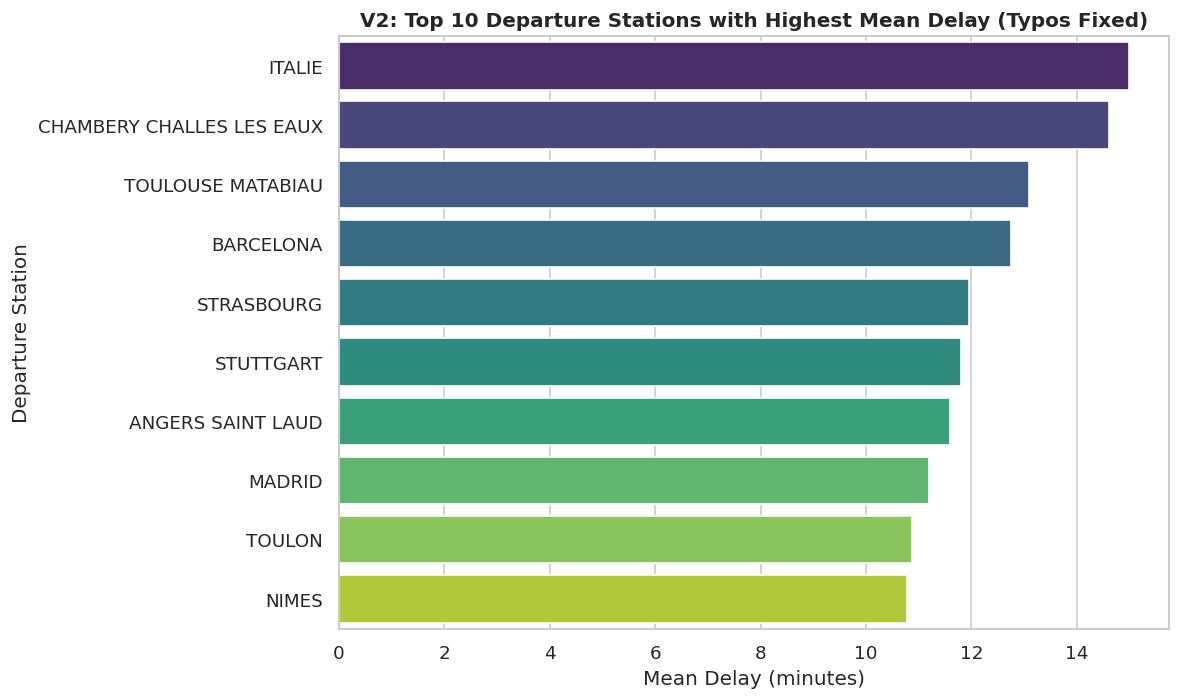

In [72]:
# Cell 15: Cleaned Top 10 Worst Performing Departure Stations (V2)
top_10_stations_v2 = (
    df_cleaned.groupby("Departure station")["Average delay of all trains at arrival"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Reset index and cast to string to fix Seaborn categorical layout compression
plot_data_v2 = top_10_stations_v2.reset_index()
plot_data_v2["Departure station"] = plot_data_v2["Departure station"].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data_v2,
    x="Average delay of all trains at arrival",
    y="Departure station",
    palette="viridis",
)

plt.title(
    "V2: Top 10 Departure Stations with Highest Mean Delay (Typos Fixed)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Mean Delay (minutes)")
plt.ylabel("Departure Station")
plt.tight_layout()
plt.show()